# The same PSHA in OpenQuake

**Geotechnical Hazards** · tutorial for Lectures 10 and 11

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pstafford/geohazards-psha/blob/main/notebooks/02_psha_with_openquake.ipynb)

[OpenQuake](https://github.com/gem/oq-engine) is the open-source hazard and risk software of the
Global Earthquake Model (GEM) Foundation, used for national seismic hazard models and the global
hazard map. Here we build the toy model of the lectures with OpenQuake's `hazardlib` and check that
our own calculation (notebook 1, `psha_toy.py`) gives the same hazard. Real software, same answer:
there is nothing magic inside it.

**The first cell installs OpenQuake on Colab (about a minute).** The hazard calculation itself takes
a minute or two. Run the cells in order; numbers you can change are marked ✏️.

In [1]:
# Setup: on Colab, install OpenQuake and download the course code.
# (GDAL, which OpenQuake uses only for GIS files, is skipped: it is slow to install.)
import os, sys, subprocess
if "google.colab" in sys.modules:
    pip = [sys.executable, "-m", "pip", "install", "-q"]
    subprocess.run(pip + ["--no-deps", "openquake.engine==3.26.2"], check=True)
    subprocess.run(pip + ["h3", "alpha_shapes", "pyzmq", "fiona", "toml", "decorator", "psutil", "numba"], check=True)
    if not os.path.exists("geohazards-psha"):
        subprocess.run(["git", "clone", "-q", "https://github.com/pstafford/geohazards-psha"], check=True)
    sys.path.insert(0, "geohazards-psha/psha")
else:
    sys.path.insert(0, os.path.abspath("../psha"))

import time, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psha_toy as pt

import openquake.hazardlib
from openquake.hazardlib.geo import Point, Line, Polygon, NodalPlane
from openquake.hazardlib.pmf import PMF
from openquake.hazardlib.source import SimpleFaultSource, AreaSource
from openquake.hazardlib.mfd import YoungsCoppersmith1985MFD, TruncatedGRMFD
from openquake.hazardlib.scalerel import WC1994, PointMSR
from openquake.hazardlib.tom import PoissonTOM
from openquake.hazardlib.site import Site, SiteCollection
from openquake.hazardlib.gsim.chiou_youngs_2014 import ChiouYoungs2014
from openquake.hazardlib.calc.hazard_curve import calc_hazard_curves
from openquake.hazardlib.calc.filters import SourceFilter, IntegrationDistance
from openquake.hazardlib.sourceconverter import SourceGroup

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.3, "font.size": 12})
P = pt.PARAMS
logging.getLogger().setLevel(logging.ERROR)  # quieten OpenQuake's progress messages
from importlib.metadata import version
print("OpenQuake", version("openquake.engine"))

OpenQuake 3.26.2


## 1. Coordinates

OpenQuake works in longitude and latitude. We put the site at (0°, 0°) and convert the model's
kilometres near the equator, where one degree is 111.195 km (OpenQuake's Earth radius × π/180).

In [2]:
TRT = "Active Shallow Crust"                # tectonic region type: which GMM applies
KM_PER_DEG = 111.19492664455873

def lonlat(x, y):
    return x / KM_PER_DEG, y / KM_PER_DEG

site = SiteCollection([Site(Point(0.0, 0.0), vs30=P["vs30"], vs30measured=True, z1pt0=-999)])

## 2. The fault

A `SimpleFaultSource`: a trace, a dip, a depth range, a magnitude–frequency distribution and a
magnitude-scaling relationship. `YoungsCoppersmith1985MFD.from_total_moment_rate` does the moment
balance of notebook 1 for us.

In [3]:
y = P["fault_dist"]
trace = Line([Point(*lonlat(-P["fault_left"], y)), Point(*lonlat(P["fault_right"], y))])
fault_area = (P["fault_left"] + P["fault_right"]) * (P["fault_bottom"] - P["fault_top"]) * 1e6   # m^2
moment_rate = P["shear_modulus"] * fault_area * P["fault_slip_rate"] / 1000                      # N m / yr

fault = SimpleFaultSource(
    "fault", "Fault", TRT,
    YoungsCoppersmith1985MFD.from_total_moment_rate(P["fault_mmin"], P["fault_b"], P["fault_mchar"], moment_rate, P["dm"]),
    rupture_mesh_spacing=P["mesh"], magnitude_scaling_relationship=WC1994(), rupture_aspect_ratio=P["aspect"],
    temporal_occurrence_model=PoissonTOM(1.0),
    upper_seismogenic_depth=P["fault_top"], lower_seismogenic_depth=P["fault_bottom"],
    fault_trace=trace, dip=90.0, rake=0.0)

## 3. The area source

An `AreaSource`: a polygon (here a 360-sided circle), a truncated Gutenberg–Richter distribution,
point ruptures (`PointMSR`) at a fixed depth, gridded every 2 km. OpenQuake's Gutenberg–Richter
uses $a$ and $b$, so we find the $a$ that gives 0.5 earthquakes of $M \geq 5$ per year.

In [4]:
R = P["area_radius"]
polygon = Polygon([Point(*lonlat(R * np.cos(t), R * np.sin(t))) for t in np.radians(np.arange(360.0))])
b, m0, m1 = P["area_b"], P["area_mmin"], P["area_mmax"]
a = np.log10(P["area_rate"] / (10**(-b * m0) - 10**(-b * m1)))

area = AreaSource(
    "area", "Area", TRT, TruncatedGRMFD(m0, m1, P["dm"], a, b),
    rupture_mesh_spacing=P["mesh"], magnitude_scaling_relationship=PointMSR(), rupture_aspect_ratio=1.0,
    temporal_occurrence_model=PoissonTOM(1.0), upper_seismogenic_depth=0.0, lower_seismogenic_depth=P["fault_bottom"],
    nodal_plane_distribution=PMF([(1.0, NodalPlane(0.0, 90.0, 0.0))]),
    hypocenter_distribution=PMF([(1.0, P["area_depth"])]),
    polygon=polygon, area_discretization=P["area_grid"])

## 4. Same ruptures?

OpenQuake generates the ruptures itself. Count them and compare with our scenario table:

In [5]:
sc = pt.scenarios()
for src, k in ((fault, 0), (area, 1)):
    n_oq = sum(1 for _ in src.iter_ruptures())
    print(f"{src.name:5s}: OpenQuake {n_oq:,} ruptures, psha_toy {int((sc['source'] == k).sum()):,}")

Fault: OpenQuake 20,864 ruptures, psha_toy 20,864


Area : OpenQuake 57,615 ruptures, psha_toy 57,615


## 5. Hazard curves

`calc_hazard_curves` returns the probability of exceedance in one year, $1 - e^{-\lambda}$; we
convert it back to a rate, $\lambda = -\ln(1 - P)$, to compare with notebook 1.

In [6]:
periods = [0.0, 0.3, 1.0, 3.0]              # ✏️ periods (s); 0 means PGA
imls = np.logspace(-3, 0.7, 60)
imt = lambda T: "PGA" if T == 0 else f"SA({T})"

t = time.time()
poes = calc_hazard_curves([SourceGroup(TRT, [fault, area])], SourceFilter(site, IntegrationDistance.new("300")),
                          {imt(T): imls for T in periods}, {TRT: ChiouYoungs2014()}, truncation_level=P["trunc"])
oq = {T: -np.log1p(-poes[imt(T)][0]) for T in periods}
print(f"OpenQuake: {time.time() - t:.0f} s")

t = time.time()
mine = {T: pt.hazard_curve(T, imls, sc) for T in periods}
print(f"psha_toy:  {time.time() - t:.0f} s")

OpenQuake: 34 s


psha_toy:  0 s


,IM,return period (yr),OpenQuake (g),psha_toy (g),difference (%)
0,PGA,475,0.3065,0.3063,-0.06
1,PGA,2475,0.4914,0.4910,-0.06
2,SA(0.3),475,0.6144,0.6140,-0.07
3,SA(0.3),2475,1.0199,1.0192,-0.07
4,SA(1.0),475,0.1614,0.1613,-0.05
5,SA(1.0),2475,0.2735,0.2733,-0.05
6,SA(3.0),475,0.0333,0.0333,-0.02
7,SA(3.0),2475,0.0586,0.0586,-0.02


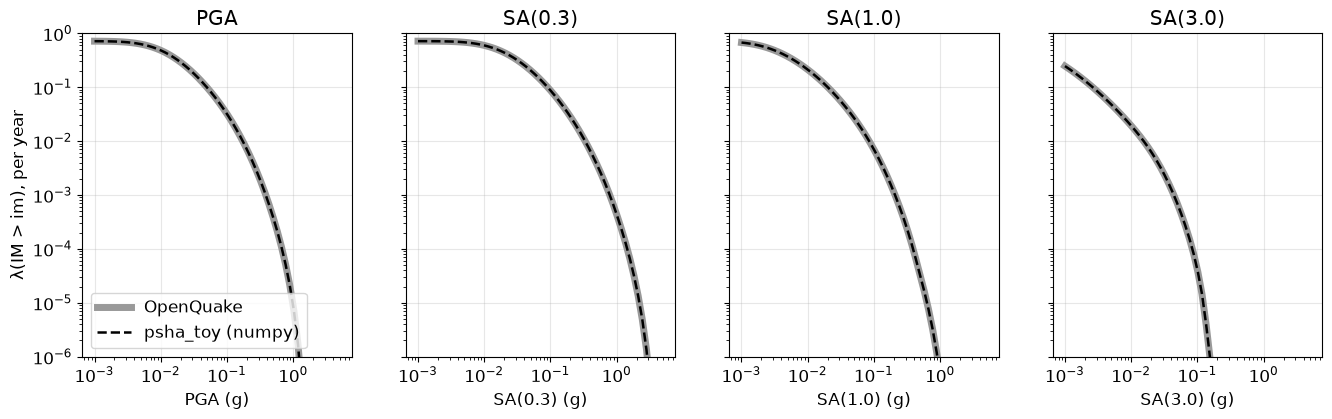

In [7]:
fig, axs = plt.subplots(1, len(periods), figsize=(4 * len(periods), 4.2), sharey=True)
for ax, T in zip(axs, periods):
    ax.loglog(imls, oq[T], color="0.6", lw=5, label="OpenQuake")
    ax.loglog(imls, mine[T], "k--", lw=1.8, label="psha_toy (numpy)")
    ax.set(xlabel=imt(T) + " (g)", ylim=(1e-6, 1), title=imt(T))
axs[0].set_ylabel("λ(IM > im), per year")
axs[0].legend();

def at_rate(lam, rate):                     # interpolate the curve (log-log) at an annual rate
    ok = lam > 0
    return np.exp(np.interp(np.log(rate), np.log(lam[ok][::-1]), np.log(imls[ok][::-1])))

rows = []
for T in periods:
    for rp in (475, 2475):
        x, y = at_rate(oq[T], 1 / rp), at_rate(mine[T], 1 / rp)
        rows.append({"IM": imt(T), "return period (yr)": rp, "OpenQuake (g)": round(x, 4),
                     "psha_toy (g)": round(y, 4), "difference (%)": round(100 * (y / x - 1), 2)})
pd.DataFrame(rows)

The two agree to within about 0.1 %: the remaining differences are numerical details (for
example, OpenQuake computes distances on a sphere, and we on a plane).

## 6. Your turn

✏️ Change a parameter in the cell below (for example the slip rate or the area source's b-value),
rebuild both models, and check that they still agree. In OpenQuake the change goes into the source
definitions of sections 2 and 3; `psha_oq.py` wraps them as functions that take the parameters.

In [8]:
import psha_oq as po
changes = {"fault_slip_rate": 15, "area_b": 0.9}      # ✏️ any key of P
p = dict(P); p.update(changes)
T = 1.0
oq_c = po.hazard_curves([T], imls, p)[T]
mine_c = pt.hazard_curve(T, imls, pt.scenarios(p), p)
for rp in (475, 2475):
    x, y = at_rate(oq_c, 1 / rp), at_rate(mine_c, 1 / rp)
    print(f"{imt(T)} at {rp} yr: OpenQuake {x:.4f} g, psha_toy {y:.4f} g ({100 * (y / x - 1):+.2f} %)")

SA(1.0) at 475 yr: OpenQuake 0.1590 g, psha_toy 0.1589 g (-0.06 %)
SA(1.0) at 2475 yr: OpenQuake 0.2751 g, psha_toy 0.2749 g (-0.06 %)


## Going further

The OpenQuake *engine* runs the same calculation from input files (`job.ini` and XML source models),
with logic trees for epistemic uncertainty, disaggregation and many sites; see the
[OpenQuake manual](https://docs.openquake.org/oq-engine/manual/latest/).